## Task 5(b): Take a binary image & a structuring element, perform Opening & Closing morphological operations.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Function for Erosion

In [2]:
def erosion(image, structuring_element):
    eroded_image = image.copy()
    structuring_element = structuring_element * 255
    offset = structuring_element.shape[0] // 2
    height, width = image.shape

    for r in range(height):
        for c in range(width):
            fit = True
            for x in range(-offset, offset + 1):
                for y in range(-offset, offset + 1):
                    if (r + x >= 0 and r + x < height and c + y >= 0 and c + y < width):
                        sr, sc = x + offset, y + offset
                        if (structuring_element[sr, sc] and image[r + x, c + y] != structuring_element[sr, sc]):
                            fit = False
                    elif (structuring_element[x + offset, y + offset]):
                        fit = False
            eroded_image[r, c] = 255 if fit else 0

    return np.uint8(eroded_image)

## Function for Dilation

In [3]:
def dilation(image, structuring_element):
    dilated_image = image.copy()
    structuring_element = structuring_element * 255
    offset = structuring_element.shape[0] // 2
    height, width = image.shape

    for r in range(height):
        for c in range(width):
            hit = False
            for x in range(-offset, offset + 1):
                for y in range(-offset, offset + 1):
                    if (r + x >= 0 and r + x < height and c + y >= 0 and c + y < width):
                        sr, sc = x + offset, y + offset
                        if (structuring_element[sr, sc] and image[r + x, c + y] == structuring_element[sr, sc]):
                            hit = True
            dilated_image[r, c] = 255 if hit else 0

    return np.uint8(dilated_image)

 ## Function for Opening

In [4]:
def opening(image, structuring_element):
    return dilation(erosion(image, structuring_element), structuring_element)

## Function for Closing

In [5]:
def closing(image, structuring_element):
    return erosion(dilation(image, structuring_element), structuring_element)

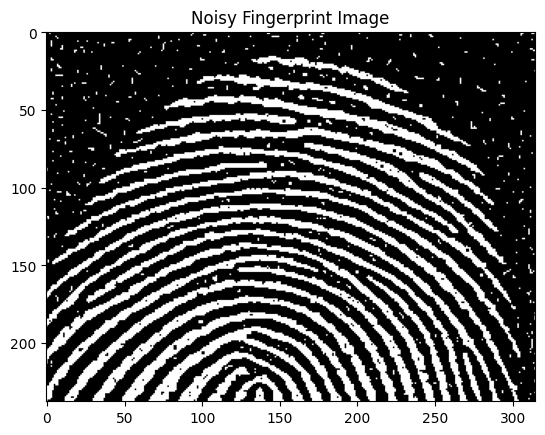

In [6]:
noisy_fingerprint = cv2.imread("./Noisy Fingerprint 315x238.tif", 0)
plt.imshow(noisy_fingerprint, cmap = "gray")
plt.title("Noisy Fingerprint Image")
plt.show()

## Creating Structuring Element

In [8]:
structuring_element_size = 3
structuring_element = np.ones((structuring_element_size, structuring_element_size))

## Applying Opening

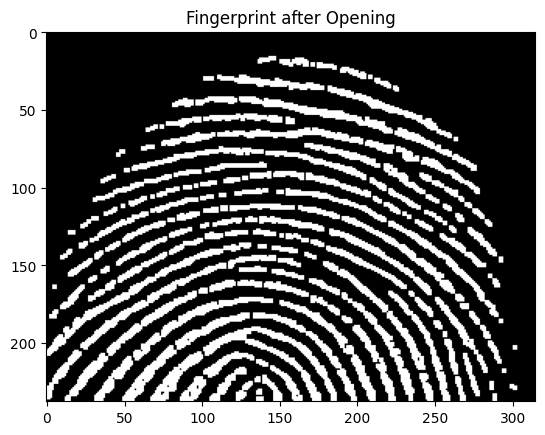

In [9]:
fingerprint_after_opening = opening(noisy_fingerprint, structuring_element)
plt.imshow(fingerprint_after_opening, cmap = "gray")
plt.title("Fingerprint after Opening")
plt.show()

## Applying Closing

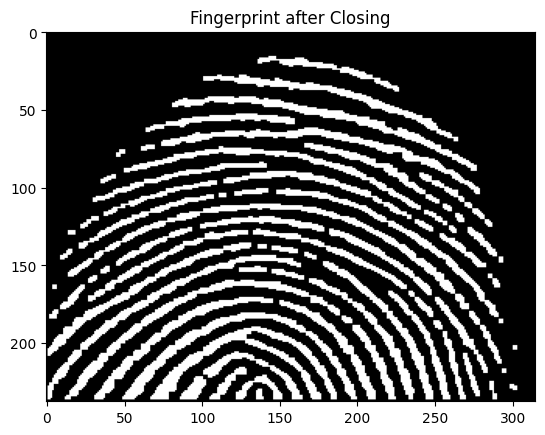

In [10]:
fingerprint_after_closing = closing(fingerprint_after_opening, structuring_element)
plt.imshow(fingerprint_after_closing, cmap = "gray")
plt.title("Fingerprint after Closing")
plt.show()